# Pupillometry

## 0. Initialization

In [1]:
import warnings
import sys 
if not sys.warnoptions:
    warnings.filterwarnings("ignore", category=DeprecationWarning)
import os 
import random
import numpy as np
import time
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns 
from itertools import combinations
import time

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import Formula

from utils import *


## 1. Data Loading Functions

In [2]:
def get_pupil_subs():
    eyetracking_subs = []
    for s in os.listdir(eyetracking_dir):
        if s[0] != ".":
            eyetracking_subs.append(int(s[1:]))

    learn_subs = []
    prepost_subs = []
    
    for s in eyetracking_subs:
        datapath_learn = f'pupil_preproc_learn_s{s}.csv'
        datapath_prepost = f'pupil_preproc_prepost_s{s}.csv'
        
        subfile_learn = f'{eyetracking_dir}/s{s}/{datapath_learn}'
        if os.path.isfile(subfile_learn):
            learn_subs.append(s)
            
        subfile_prepost = f'{eyetracking_dir}/s{s}/{datapath_prepost}'
        if os.path.isfile(subfile_prepost):
            prepost_subs.append(s)
    
    return sorted(learn_subs), sorted(prepost_subs)


# gets a dataframe containing whether each trial (0-indexed) in a specific run was encoded (subject response provided)
def get_encoded_df(subid, run):
    behav_file = f'./data/behavior/catStats_sub{subid}.csv'
    behav_data = pd.read_csv(behav_file, sep='\t')
    behav_data_run = behav_data[behav_data.block == run].reset_index(drop=True)[["blocktrial", "block", "encoded"]]
    behav_data_run = behav_data_run.rename(columns={"blocktrial": "trial"})
    return behav_data_run


# load pupil data from a specific subject
def load_sub_pupil(subnum, with_encoded=False):
    subdata = []

    datapath_learn = f'pupil_preproc_learn_s{subnum}.csv'
    datapath_prepost = f'pupil_preproc_prepost_s{subnum}.csv'
    
    subfile_learn = f'{eyetracking_dir}/s{subnum}/{datapath_learn}'
    if os.path.isfile(subfile_learn):
        subdata.append(pd.read_csv(subfile_learn).drop(columns=["Unnamed: 0"]))
    
    subfile_prepost = f'{eyetracking_dir}/s{subnum}/{datapath_prepost}'
    if os.path.isfile(subfile_prepost):
        subdata.append(pd.read_csv(subfile_prepost).drop(columns=["Unnamed: 0"]))
    
    subdata = pd.concat(subdata)
    
    if with_encoded:
        encoded_dfs = []
        for run in [1, 2, 3, 4, 5]:
            encoded_df = get_encoded_df(subnum, run)
            encoded_df["trial"] = encoded_df["trial"].apply(lambda x: x+1) # convert 0-indexed trials to 1-indexed, as used in pupil
            encoded_dfs.append(encoded_df)
        encoded_dfs = pd.concat(encoded_dfs)

        subdata = pd.merge(subdata, encoded_dfs, on=["trial", "block"], how="left")

    return subdata


## 2. Get subjects with pupillometry data

In [3]:
# basic variables
conds = ["A", "B", "X"]
prelearn_runs = [1]
learn_runs = [2, 3, 4]
n_trialsperrun = 84
palette = ABX_colors
encoded_only = True

# subject information
learn_subs, prepost_subs = get_pupil_subs()
eyetracking_subs = np.union1d(learn_subs, prepost_subs)

subinfo = pd.read_csv('./data/subject_info.txt', sep="\t")
sub2grp = subinfo[["subid", "group"]]

eyetracking_subinfo = sub2grp[np.isin(np.array(sub2grp["subid"]), eyetracking_subs)]
eyetracking_sub2grp = {int(eyetracking_subinfo.iloc[i]["subid"]):int(eyetracking_subinfo.iloc[i]["group"]) for i in range(len(eyetracking_subs))}

eyetracking_ctrl_subs = list(eyetracking_subinfo[eyetracking_subinfo["group"] == 0]["subid"])
eyetracking_stress_subs = list(eyetracking_subinfo[eyetracking_subinfo["group"] == 1]["subid"])

print(f"Control: {len(eyetracking_ctrl_subs)}")
print(f"Stress: {len(eyetracking_stress_subs)}")


Control: 28
Stress: 33


### Count excluded trials

In [4]:
use_subs = eyetracking_subs
use_runs = prelearn_runs + learn_runs

n_badpupil = 0
n_badresp = 0

for sub in use_subs:
    sub_pupil = load_sub_pupil(sub, with_encoded=True)
    for run in use_runs:
        cur_pupil = sub_pupil[sub_pupil["block"] == run]
        cur_pupil_good = cur_pupil[cur_pupil["encoded"] == 1]
        cur_pupil_badresp = cur_pupil[cur_pupil["encoded"] == 0]

        cur_n_badresp = len(np.unique(cur_pupil_badresp["trial"]))
        cur_n_good = len(np.unique(cur_pupil_good["trial"]))
        
        n_badresp += cur_n_badresp
        n_badpupil += n_trialsperrun - cur_n_good - cur_n_badresp
        
expect_n = len(use_subs)*n_trialsperrun*len(use_runs)
print(f"Total expected trials: {expect_n}")
print(f"Trials excluded for bad pupil: {n_badpupil} ({100*n_badpupil/expect_n}%)")
print(f"Trials excluded for bad response: {n_badresp} ({100*n_badresp/expect_n}%)")


Total expected trials: 20496
Trials excluded for bad pupil: 599 (2.922521467603435%)
Trials excluded for bad response: 144 (0.702576112412178%)


## 3. Plot average pupil trace across subjects (Figure 2A top)

In [5]:
def get_pupil_trace(sub, runs, window = 300, encoded_only=False):
    '''
    Args: 
        sub (int): subject id number
        runs (list(int)): list of run numbers
        window (int): the window of time to take into account starting from trial onset
        encoded_only (bool): default False; if True, only takes into account trials with behavioral response
        
    Returns:
        pandas dataframe: columns ["Timebin", "cond", "ps.adj", "subid", "group"]
    '''
    
    subdata = load_sub_pupil(sub, with_encoded=encoded_only)
    if encoded_only:
        subdata = subdata.loc[subdata["encoded"] == 1]
    
    subdata = subdata[np.isin(np.array(subdata["block"]), runs)]
    subdata_trim = subdata.loc[subdata["Timebin"] < window][["trial", "Timebin", "cond", "ps.adj"]]
    
    sub_df = subdata_trim.groupby(["Timebin", "cond"]).mean().reset_index()[["Timebin", "cond", "ps.adj"]]
    sub_df["subid"] = [sub]*len(sub_df)
    sub_df["group"] = [eyetracking_sub2grp[sub]]*len(sub_df)
    
    return sub_df


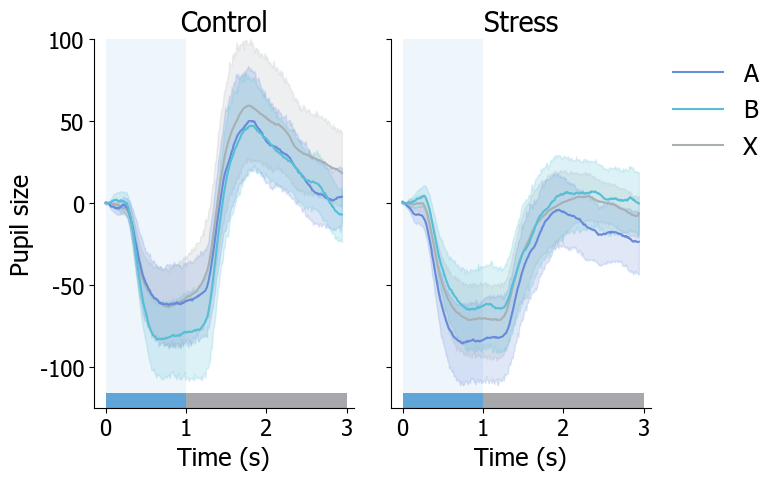

In [6]:
# get data
df_prebase = []

for sub in eyetracking_subs:
    # extract 3s pupil trace for A/B/X images
    sub_learn_df = get_pupil_trace(sub, learn_runs, window=295, encoded_only=encoded_only)

    # extract 3s pupil trace for A/B/X images BEFORE LEARNING as a baseline
    sub_prelearn_df = get_pupil_trace(sub, prelearn_runs, window=295, encoded_only=encoded_only).rename(columns={"ps.adj": "pre.ps.adj"})

    # merge and subtract baseline
    sub_prebase_df = pd.merge(sub_learn_df, sub_prelearn_df, on=["Timebin", "cond", "group", "subid"])
    sub_prebase_df["ps.adj.prebase"] = sub_prebase_df["ps.adj"] - sub_prebase_df["pre.ps.adj"]

    df_prebase.append(sub_prebase_df)

# combine data across subjects
df_prebase = pd.concat(df_prebase).reset_index(drop=True)


# visualize pupil trace
conds = ["A", "B", "X"]
palette = [ABX_colors[0], ABX_colors[1], adjust_lightness(ABX_colors[2], 0.9)]
orderi = [2, 0, 1]
orderi_rev = [1, 2, 0]

# plot baselined pupil trace during learning
g = sns.FacetGrid(data=df_prebase, col="group", height=5, aspect=0.7)
g.map_dataframe(sns.lineplot, x="Timebin", y="ps.adj.prebase", hue="cond", hue_order=[conds[i] for i in orderi], palette=[palette[i] for i in orderi])
#g.add_legend()

for grp, grpname in zip([0, 1], ["Control", "Stress"]):
    ax = g.facet_axis(0, grp)
    ax.set_ylim([-125, 100])
    ax.set_title(grpname, fontsize=20)
    ax.set_xlabel("Time (s)", fontsize=18)
    ax.set_xticks(np.arange(0, 301, 100))
    ax.set_xticklabels([f'{i:.00f}' for i in np.arange(0, 3.1, 1)], fontsize=16)
    ax.set_yticks(np.arange(-100, 101, 50))
    ax.set_yticklabels(np.arange(-100, 101, 50), fontsize=16)
    ax.set_ylabel("Pupil size", fontsize=18)
    
    # add a transparent patch
    patch_range = [0, 100] # in timesamples at 100Hz
    rect_position = (patch_range[0] - ax.get_xlim()[0])/np.diff(ax.get_xlim())[0]
    rect_width = (np.diff(patch_range)[0])/np.diff(ax.get_xlim())[0]
    rect_height = 1
    rect = mpl.patches.Rectangle((rect_position, 0), width=rect_width, height=rect_height, color="#5fa5d8", transform=ax.transAxes, clip_on=False, linewidth=0, alpha=0.1)
    rect.set_zorder(0)
    ax.add_patch(rect)
    
    # add patches to indicate trial vs ISI
    ranges = [[0, 100], [100, 300]]
    range_colors = ["#5fa5d8", rest_color]
    trial_height = (100/np.diff(ax.get_xlim())[0])/8
    for trial_range, trial_color in zip(ranges, range_colors):
        trial_position = (trial_range[0] - ax.get_xlim()[0])/np.diff(ax.get_xlim())[0]
        trial_width = (np.diff(trial_range)[0])/np.diff(ax.get_xlim())[0]
        trial_rect = mpl.patches.Rectangle((trial_position, 0), width=trial_width, height=trial_height, color=trial_color, transform=ax.transAxes, clip_on=False, linewidth=0)
        trial_rect.set_zorder(0)
        ax.add_patch(trial_rect)
    
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=[handles[i] for i in orderi_rev], labels = [labels[i] for i in orderi_rev], fontsize=18, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)


## 4. Plot mean pupil size during stimulus presentation (Figure 2A bottom)

Control A vs B: 95% CI [1.9975609399890506, 20.28068385723836], p=0.018060180601806017, r=0.4827586206896552
Control B vs X: 95% CI [-19.68374803719995, -1.6164091605484623], p=0.02140021400214002, r=-0.46798029556650245
Control A vs X: 95% CI [-12.34625994383423, 13.491161629708238], p=0.9357693576935769, r=0.019704433497536922
Stress A vs B: 95% CI [-31.361795420374403, -4.3224792679104205], p=0.007840078400784007, r=-0.483065953654189
Stress B vs X: 95% CI [-4.740405504436114, 17.546680925562537], p=0.27336273362733626, r=0.2513368983957219
Stress A vs X: 95% CI [-21.284331851164882, -1.8470713485484627], p=0.017880178801788018, r=-0.376114081996435


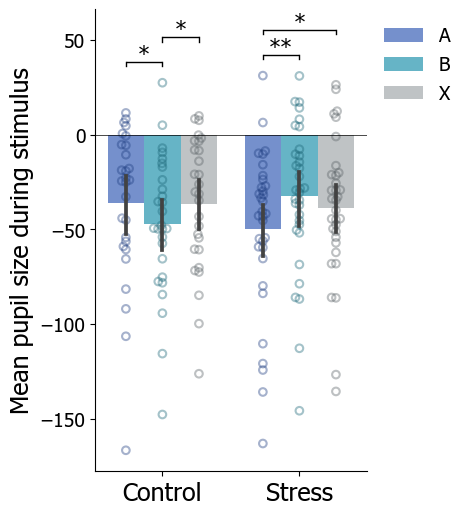

In [7]:
np.random.seed(0)

palette = ABX_colors
dark_palette = [adjust_lightness(p) for p in palette]

timebin_range = [0, 100]
conds = ["A", "B", "X"]
groups = ["Control", "Stress"]

df_prebase_trim = df_prebase.loc[(df_prebase["Timebin"] >= timebin_range[0]) & (df_prebase["Timebin"] < timebin_range[1])]
df_prebase_avg = df_prebase_trim.groupby(["cond", "group", "subid"]).mean().reset_index().drop(columns=["Timebin", "ps.adj", "pre.ps.adj"])
df_prebase_avg["group"] = df_prebase_avg["group"].apply(lambda x: {0: "Control", 1: "Stress"}[x])

df_prebase_avg = df_prebase_avg[np.isin(df_prebase_avg["cond"], conds)]

fig, ax = plt.subplots(1, 1, figsize=(3.5, 6))
sns.barplot(data=df_prebase_avg, x="group", y="ps.adj.prebase", hue="cond", palette=palette)
sns.swarmplot(data=df_prebase_avg, x="group", y="ps.adj.prebase", hue="cond", dodge=True, s=9/len(conds), alpha=0, legend=False)

for groupi in range(len(groups)):
    for condi in range(len(conds)):
        i = groupi*len(conds) + condi
        x_data, y_data = ax.collections[i].get_offsets().T
    
        ax.scatter(x_data, y_data, color="None", s=30, alpha=0.4, edgecolor=dark_palette[condi], linewidth=1.5)


# add significance stars
barxs, barys = get_star_x_y(ax, df_prebase_avg, xcol="group", huecol="cond", valcol="ps.adj.prebase", xorder=groups, hueorder=conds)
yshift = np.diff(ax.get_ylim())[0]*0.05

# within-group comparisons
compare_df = df_prebase_avg.pivot(index=["subid", "group"], columns="cond", values="ps.adj.prebase").reset_index().dropna()

for i in range(len(groups)):
    max_stary = 0
    curx = groups[i]

    # get data for this x
    x_df = compare_df.loc[(compare_df["group"] == curx)]

        
    barpairs = list(combinations(np.arange(len(conds)), 2))
    pairord = np.argsort([np.diff(p)[0] for p in barpairs])
    barpairs_sorted = np.array(barpairs)[pairord]
    
    for pairidx in barpairs_sorted:
        condpair = np.array(conds)[pairidx]
        val1 = np.array(x_df[condpair[0]])
        val2 = np.array(x_df[condpair[1]])
    
        CI, pval = simple_bootstrap(val1 - val2, iterations=99999, onetail_hyp="any")
        pval=2*pval
        rbc = wilcoxon_effsize(val1-val2)
        print(f"{curx} {' vs '.join(condpair)}: 95% CI {CI}, p={pval}, r={rbc}")
        star = pval2star(pval)
        
        linex = barxs[i][pairidx]
        starx = np.mean(linex)
        stary = np.max(barys[i][pairidx]) + yshift
        
        if star != '':
            if star == '~':
                continue
            
            if stary <= max_stary + yshift*1.2:
                stary = max_stary + yshift*1.2
            
            ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
            ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
            ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
            
            ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
            
            if stary > max_stary:
                max_stary = stary
               

auto_ylim = ax.get_ylim()
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel("Mean pupil size during stimulus", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=14)
ax.set_xlabel("")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14, frameon=False)
sns.despine()


In [8]:
# evaluating group differences via LME
formula_lme = f"ps.adj.prebase ~ cond*group"
random_lme = "~ 1 | subid"
anova_lme, effsize_lme = r_lme(df_prebase_avg, formula=formula_lme, random_formula=random_lme, effsize=True)

print(anova_lme)
print(effsize_lme[["partial.etasq", "statistic"]])


ps.adj.prebase ~ cond * group + (1 | subid)

             numDF  denDF    F-value       p-value
(Intercept)      1  118.0  85.632064  1.110223e-15
cond             2  118.0   1.086543  3.407319e-01
group            1   59.0   0.003965  9.500030e-01
cond:group       2  118.0   6.117784  2.964773e-03
            partial.etasq  statistic
cond                0.017      1.087
group               0.000      0.004
cond:group          0.088      6.118
1                     NaN        NaN


### Cortisol Effects

In [9]:
pup_AminB_df = df_prebase_avg.pivot(columns="cond", index=["subid", "group"], values="ps.adj.prebase").reset_index()
pup_AminB_df["AminB"] = pup_AminB_df["A"] - pup_AminB_df["B"]
pup_AminB_df = pup_AminB_df[["subid", "AminB"]].rename(columns={"subid": "subID"})
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(pup_AminB_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula=f"AminB ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,48.0,0.997329,0.322966
cort_react,1,48.0,1.664224,0.203215
group,1,48.0,9.427641,0.003513
cort_react:group,1,48.0,0.027283,0.869500
